In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind
import warnings
warnings.filterwarnings('ignore')
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
%matplotlib inline 

In [3]:
df = pd.read_csv('upi_transactions_2024.csv')
df.head()

,transaction id,timestamp,transaction type,merchant_category,amount (INR),transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,receiver_bank,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,SBI,Android,4G,0,15,Tuesday,0
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,Axis,iOS,4G,0,6,Thursday,0
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,PNB,Android,4G,0,13,Tuesday,0
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,PNB,Android,5G,0,10,Sunday,1
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,Yes Bank,iOS,WiFi,0,19,Tuesday,0


In [4]:
print('Number of Rows: ',df.shape[0])
print('Number of Columns: ',df.shape[1])

Number of Rows:  250000
Number of Columns:  17


In [5]:
print('Column_names: ',df.columns)

Column_names:  Index(['transaction id', 'timestamp', 'transaction type', 'merchant_category',
       'amount (INR)', 'transaction_status', 'sender_age_group',
       'receiver_age_group', 'sender_state', 'sender_bank', 'receiver_bank',
       'device_type', 'network_type', 'fraud_flag', 'hour_of_day',
       'day_of_week', 'is_weekend'],
      dtype='object')


In [6]:
df.isnull().sum()

transaction id        0
timestamp             0
transaction type      0
merchant_category     0
amount (INR)          0
transaction_status    0
sender_age_group      0
receiver_age_group    0
sender_state          0
sender_bank           0
receiver_bank         0
device_type           0
network_type          0
fraud_flag            0
hour_of_day           0
day_of_week           0
is_weekend            0
dtype: int64

In [7]:
#No Null Values are present

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   transaction id      250000 non-null  object
 1   timestamp           250000 non-null  object
 2   transaction type    250000 non-null  object
 3   merchant_category   250000 non-null  object
 4   amount (INR)        250000 non-null  int64 
 5   transaction_status  250000 non-null  object
 6   sender_age_group    250000 non-null  object
 7   receiver_age_group  250000 non-null  object
 8   sender_state        250000 non-null  object
 9   sender_bank         250000 non-null  object
 10  receiver_bank       250000 non-null  object
 11  device_type         250000 non-null  object
 12  network_type        250000 non-null  object
 13  fraud_flag          250000 non-null  int64 
 14  hour_of_day         250000 non-null  int64 
 15  day_of_week         250000 non-null  object
 16  is

In [9]:
# Data Cleaning and Feature Engineering

In [10]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.drop_duplicates(inplace=True)
df['amount (INR)'] = pd.to_numeric(df['amount (INR)'])
df.rename(columns={'amount (INR)':'amount'},inplace=True)
df['month'] = df['timestamp'].dt.month_name()
df['day'] = df['timestamp'].dt.day
df['hour'] = df['timestamp'].dt.hour
df['trx_bin'] = pd.qcut(df['amount'], q=4, labels=['Low','Medium','High','Very High'])

In [11]:
df

,transaction id,timestamp,transaction type,merchant_category,amount,transaction_status,sender_age_group,receiver_age_group,sender_state,sender_bank,...,device_type,network_type,fraud_flag,hour_of_day,day_of_week,is_weekend,month,day,hour,trx_bin
0,TXN0000000001,2024-10-08 15:17:28,P2P,Entertainment,868,SUCCESS,26-35,18-25,Delhi,Axis,...,Android,4G,0,15,Tuesday,0,October,8,15,High
1,TXN0000000002,2024-04-11 06:56:00,P2M,Grocery,1011,SUCCESS,26-35,26-35,Uttar Pradesh,ICICI,...,iOS,4G,0,6,Thursday,0,April,11,6,High
2,TXN0000000003,2024-04-02 13:27:18,P2P,Grocery,477,SUCCESS,26-35,36-45,Karnataka,Yes Bank,...,Android,4G,0,13,Tuesday,0,April,2,13,Medium
3,TXN0000000004,2024-01-07 10:09:17,P2P,Fuel,2784,SUCCESS,26-35,26-35,Delhi,ICICI,...,Android,5G,0,10,Sunday,1,January,7,10,Very High
4,TXN0000000005,2024-01-23 19:04:23,P2P,Shopping,990,SUCCESS,26-35,18-25,Delhi,Axis,...,iOS,WiFi,0,19,Tuesday,0,January,23,19,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
249995,TXN0000249996,2024-11-08 22:41:43,Recharge,Food,373,SUCCESS,36-45,26-35,Telangana,ICICI,...,iOS,5G,0,22,Friday,0,November,8,22,Medium
249996,TXN0000249997,2024-12-15 02:58:03,P2P,Utilities,2025,SUCCESS,36-45,26-35,Rajasthan,HDFC,...,Android,5G,0,2,Sunday,1,December,15,2,Very High
249997,TXN0000249998,2024-11-27 16:33:25,P2P,Food,468,SUCCESS,26-35,18-25,West Bengal,ICICI,...,Android,4G,0,16,Wednesday,0,November,27,16,Medium
249998,TXN0000249999,2024-01-05 13:31:30,Recharge,Healthcare,284,SUCCESS,18-25,36-45,Andhra Pradesh,Axis,...,iOS,4G,0,13,Friday,0,January,5,13,Low


### Monthly and Hourly Patterns
- Analyzing transactions by month and hour reveals seasonality and user behavior throughout the day

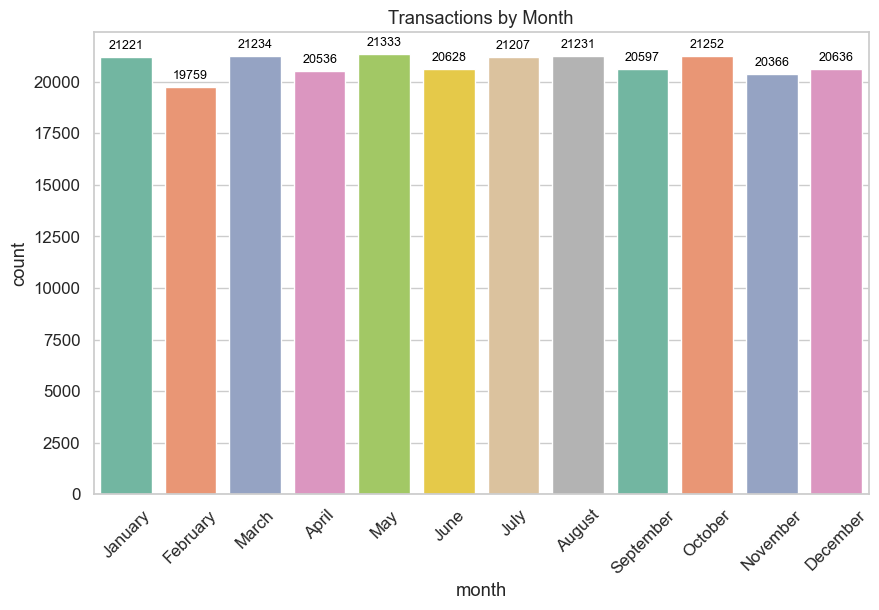

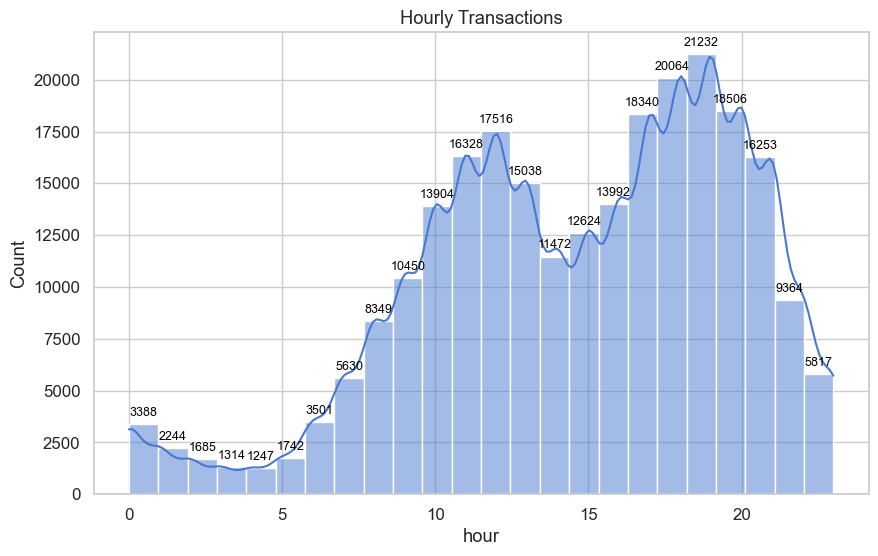

In [12]:
plt.figure(figsize=(10,6))

order = pd.date_range('2024-01-01','2024-12-01',freq='MS').strftime('%B')
ax = sns.countplot(data=df,x='month',order=order,palette='Set2')
for p in ax.patches:
        ax.annotate(int(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', 
                    xytext=(0, 8), textcoords='offset points')
plt.title('Transactions by Month')
plt.xticks(rotation=45)
plt.show()

plt.figure(figsize=(10,6))
ax = sns.histplot(df['hour'], bins=24, kde=True)

for p in ax.patches:
    ax.annotate(int(p.get_height()), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='center', 
                fontsize=9, color='black', 
                xytext=(0, 8), textcoords='offset points')

plt.title('Hourly Transactions')
plt.show()

- Transaction volumes is higher in certain months, possibly due to year end shopping.
- Most Transaction are done during bussiness hours,with dop at night.

### Sender & Receiver Demographics

- Analyzing age groups and states helps understand the user base and regional adoption.

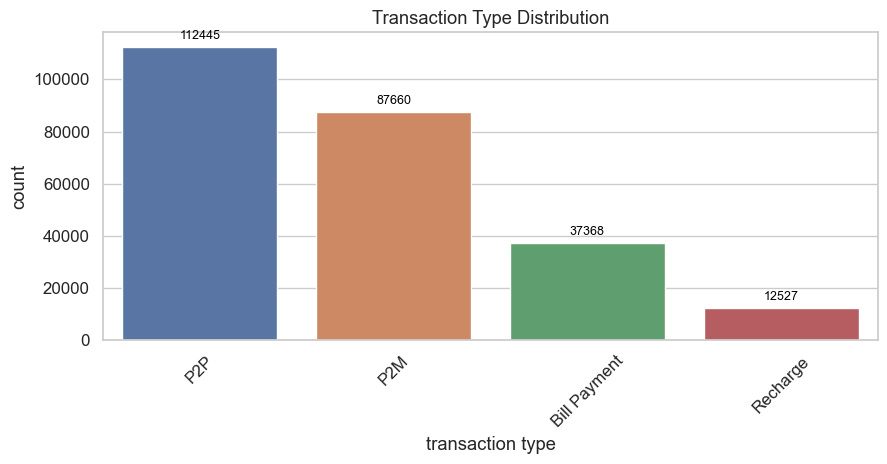

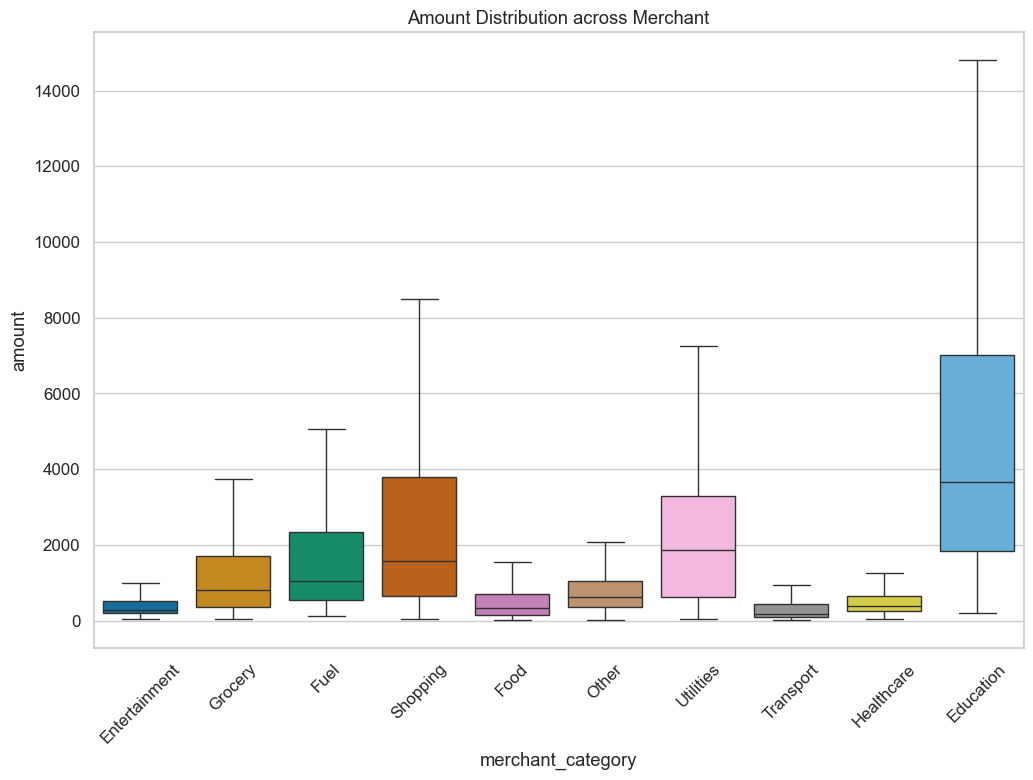

In [13]:
plt.figure(figsize=(10,4))
ax = sns.countplot(data =df,x='transaction type',palette='deep')
for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='center',fontsize=9, color='black', 
                    xytext=(0, 8), textcoords='offset points')

plt.title('Transaction Type Distribution')
plt.xticks(rotation=45)
plt.show()


plt.figure(figsize=(12,8))
ax = sns.boxplot(data=df,x='merchant_category',y='amount',palette='colorblind',showfliers=False)
plt.title('Amount Distribution across Merchant')
plt.xticks(rotation=45)
plt.show()

- There is a wide range of UPI transaction for 'Education' and 'Shopping' Category
- the P2P and P2M transaction are the most common, showing popularity for both personal and merchant payments. 

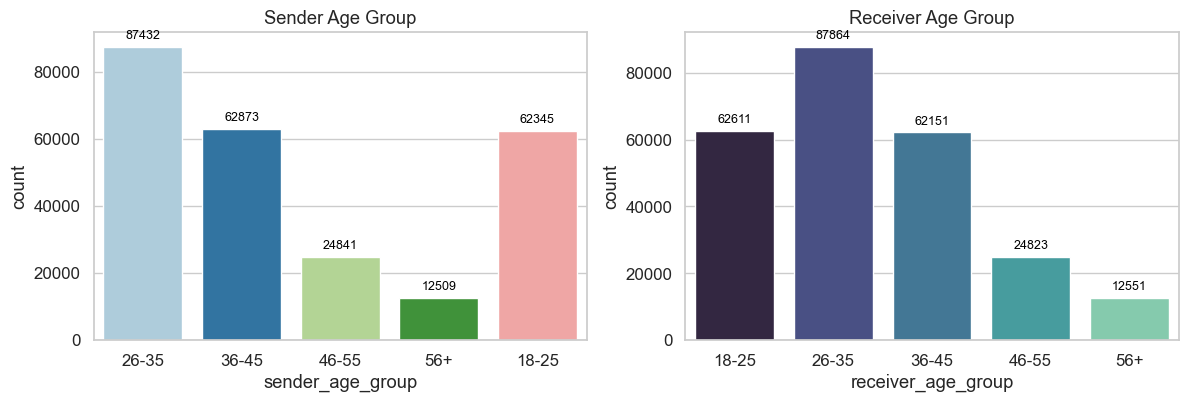

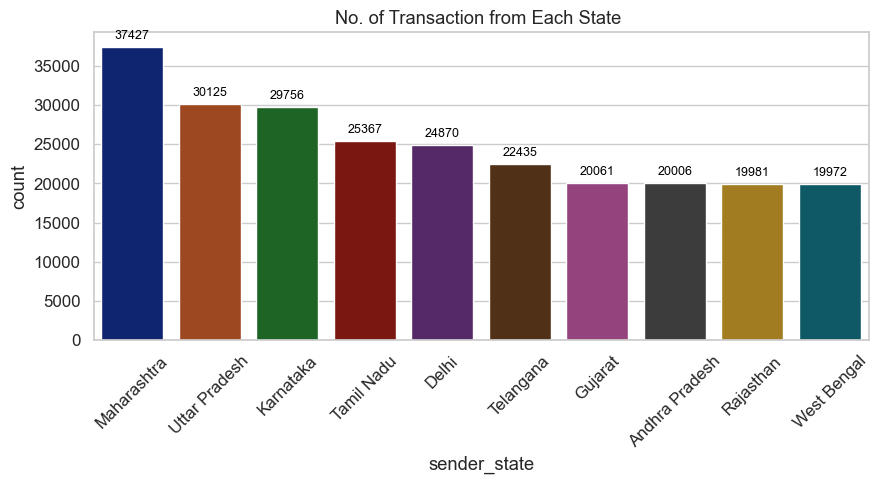

In [14]:
fig,ax = plt.subplots(1,2,figsize=(14,4))
sns.countplot(data=df,x='sender_age_group',palette='Paired',ax=ax[0])
for p in ax[0].patches:
        ax[0].annotate(int(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', 
                    xytext=(0, 8), textcoords='offset points')
ax[0].set_title('Sender Age Group')

sns.countplot(data=df,x='receiver_age_group',palette='mako',ax=ax[1])
for p in ax[1].patches:
        ax[1].annotate(int(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', 
                    xytext=(0, 8), textcoords='offset points')
ax[1].set_title('Receiver Age Group')

plt.show()

plt.figure(figsize=(10,4))
ax = sns.countplot(data=df,x='sender_state',order=df['sender_state'].value_counts().index,palette='dark')
for p in ax.patches:
        ax.annotate(int(p.get_height()), 
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', fontsize=9, color='black', 
                    xytext=(0, 8), textcoords='offset points')
plt.title('No. of Transaction from Each State ')
plt.xticks(rotation=45)
plt.show()

- Maharashtra dominates transaction volume at 37,427, suggesting mature UPI adoption supported by high smartphone penetration and a large base of digitally active users.
- Karnataka, Tamil Nadu and Telangana rank higher dispite smaller population compared to MH and UP.This suggests South India has higher per-capita UPI adoption.

### Top Banks (Senders & Receivers)

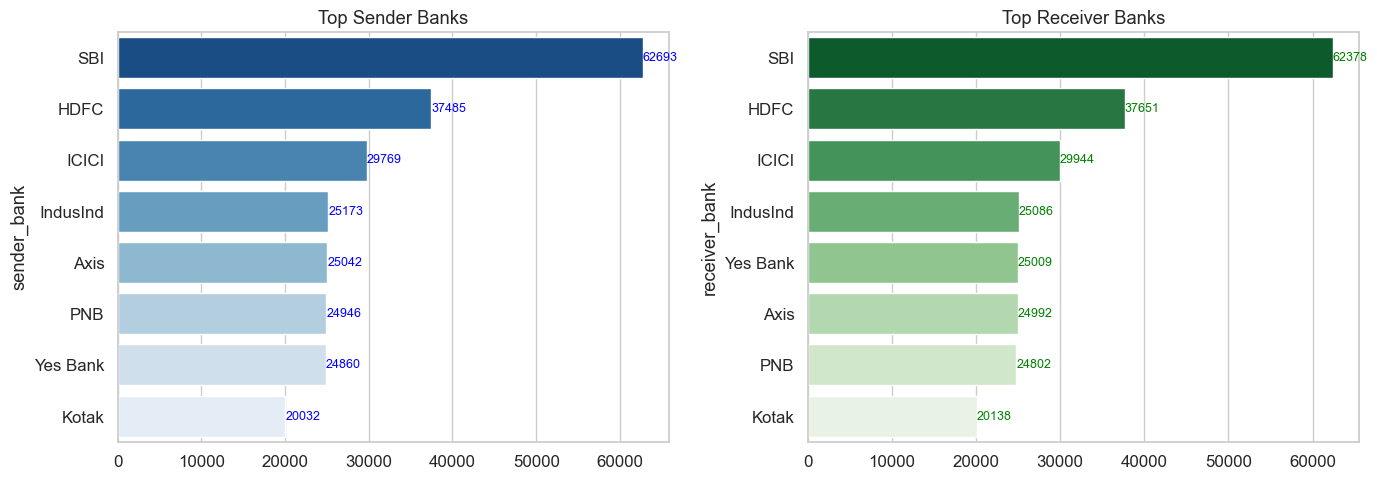

In [15]:
top_senders = df['sender_bank'].value_counts().head(10)
top_receivers = df['receiver_bank'].value_counts().head(10)
fig, ax = plt.subplots(1,2, figsize=(14,5))
sns.barplot(y=top_senders.index, x=top_senders.values, ax=ax[0], palette='Blues_r')
for i, v in enumerate(top_senders.values):
    ax[0].text(v + 1, i, str(v), color='blue', va='center', fontsize=9)
ax[0].set_title('Top Sender Banks')
sns.barplot(y=top_receivers.index, x=top_receivers.values, ax=ax[1], palette='Greens_r')
for i, v in enumerate(top_receivers.values):
    ax[1].text(v + 1, i, str(v), color='green', va='center', fontsize=9)
ax[1].set_title('Top Receiver Banks')
plt.tight_layout()
plt.show()

- SBI, HDFC, and ICICI are among the most popular banks for both sending and receiving UPI payments.

### Device Usage Pattern

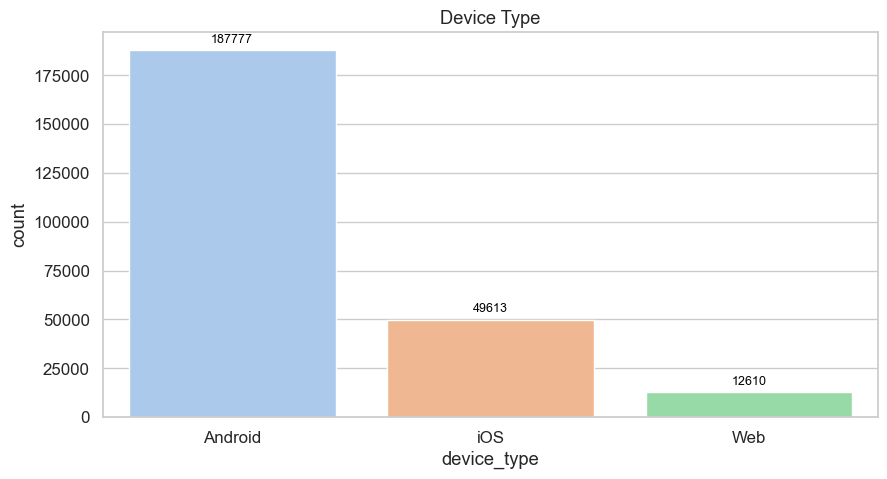

In [16]:
plt.figure(figsize=(10,5))
ax = sns.countplot(data=df, x='device_type', palette='pastel')
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=9, color='black', xytext=(0, 8), textcoords='offset points')
plt.title('Device Type')
plt.show()

- Most Transaction are done through Andriod phone, reflecting the mobile-first nature of digital payments in India.

#### Weekend vs Weekday Analysis

In [17]:
# Hypothesis 
# 1. Null Hypothesis: Mean of the Transaction amount during weekend = Mean of the Transaction amount during weekdays
# 2. Alter Hypothesis: The Means are different.
# taking the signifincae level as 0.05 i.e we are 95% confident.

In [18]:
weekend_mean = df.groupby(df['is_weekend']).agg({'amount':'mean'})
alpha = 0.05
print('Mean Transaction Amount - Weekday:', round(weekend_mean.iloc[0]['amount'],2), '| Weekend:', round(weekend_mean.iloc[1]['amount'],2))
tstat, pval = ttest_ind(df[df['is_weekend']==0]['amount'], df[df['is_weekend']==1]['amount'])
print('T-test p-value',pval)

if pval <= alpha:
    print('Reject Null Hypothesis - Significant difference exists') 
else:
    print('Fail to Reject Null Hypothesis - No significant difference between weekday and weekend amounts')

Mean Transaction Amount - Weekday: 1312.52 | Weekend: 1309.85
T-test p-value 0.7440094539352002
Fail to Reject Null Hypothesis - No significant difference between weekday and weekend amounts


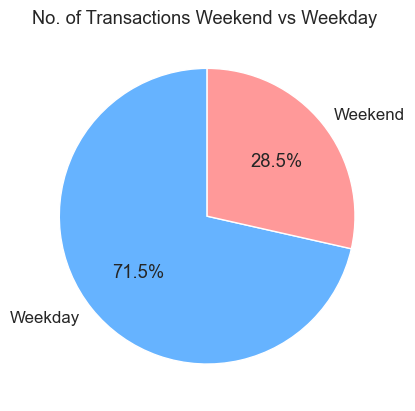

In [19]:
weekend_counts = df['is_weekend'].value_counts().sort_index()
plt.pie(weekend_counts, labels=['Weekday','Weekend'], autopct=lambda p: '{:.1f}%'.format(p) if p > 0 else '', startangle=90, colors=['#66b3ff','#ff9999'])
plt.title('No. of Transactions Weekend vs Weekday ')
plt.show()

### Transaction Value Segmentation

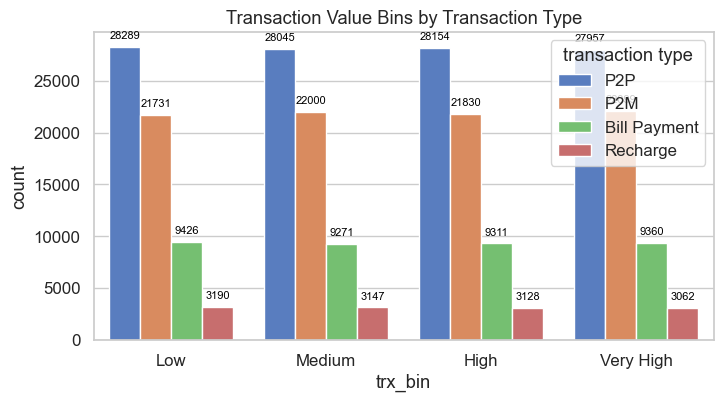

In [20]:
plt.figure(figsize=(8,4))
ax = sns.countplot(data=df, x='trx_bin', hue='transaction type')
for p in ax.patches:
    height = int(p.get_height())
    if height > 0:
        ax.annotate(height, (p.get_x() + p.get_width() / 2., height), ha='center', va='center', fontsize=8, color='black', xytext=(0, 8), textcoords='offset points')
plt.title('Transaction Value Bins by Transaction Type')
plt.show()

- P2P transaction are common across all value bins.

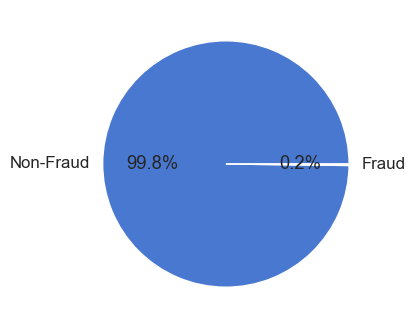

In [21]:
plt.figure(figsize=(10,4))
fraud_counts = df['fraud_flag'].value_counts()
plt.pie(fraud_counts,labels=['Non-Fraud','Fraud'],autopct='%0.1f%%')
plt.show()

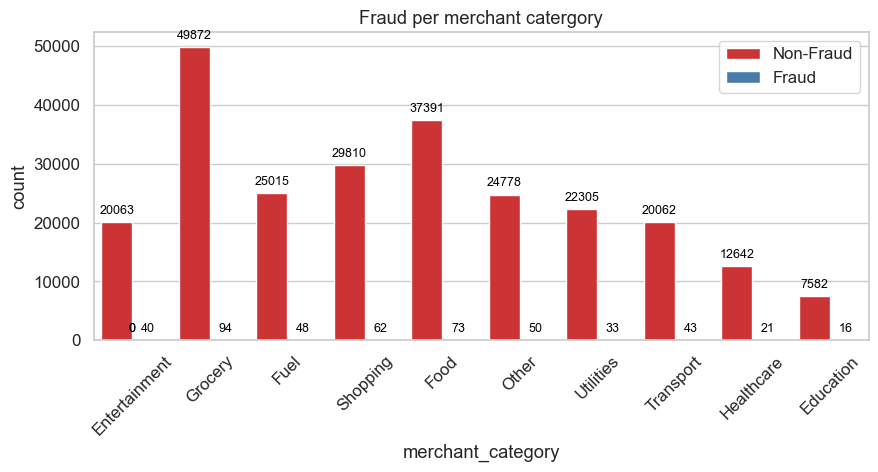

In [22]:
plt.figure(figsize=(10,4))
ax = sns.countplot(data=df,x='merchant_category',hue='fraud_flag',palette='Set1')
for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='center',fontsize=9,color='black',xytext=(0,8),
               textcoords = 'offset points')
plt.title('Fraud per merchant catergory')
plt.xticks(rotation=45)
plt.legend(['Non-Fraud','Fraud'])
plt.show()

#### Fraud Rate Per Category

In [93]:
total_fraud_per_category = df[df['fraud_flag']==1].groupby(df['merchant_category']).size()
total_transaction_per_catogory = df.groupby(df['merchant_category']).size()

fraud_rate_per_category = (total_fraud_per_category/total_transaction_per_catogory) * 100
fraud_rate_per_category = fraud_rate_per_category.reset_index()
fraud_rate_per_category.rename(columns={0:'fraud_rate'},inplace=True)
fraud_rate_per_category

,merchant_category,fraud_rate
0,Education,0.210582
1,Entertainment,0.198975
2,Food,0.194854
3,Fuel,0.191517
4,Grocery,0.188128
5,Healthcare,0.165837
6,Other,0.201386
7,Shopping,0.207552
8,Transport,0.213877
9,Utilities,0.147730


In [98]:
mer_cat = fraud_rate_per_category.value_counts().reset_index().sort_values(by='fraud_rate',ascending=False)['merchant_category']

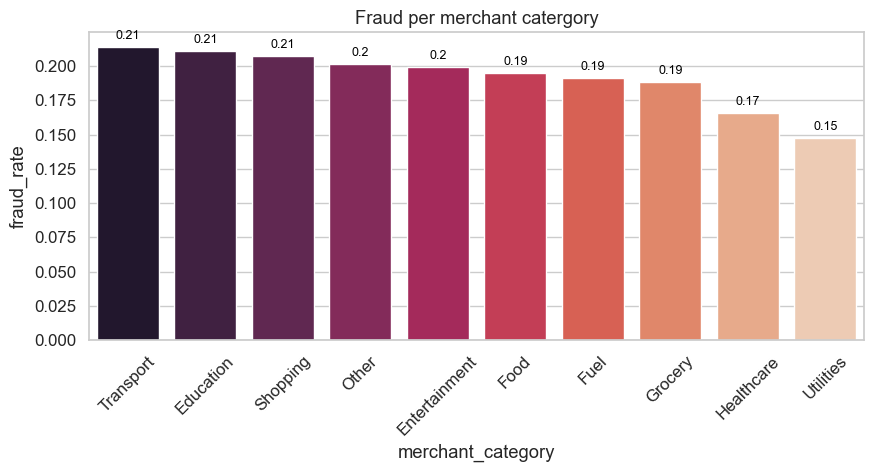

In [102]:
plt.figure(figsize=(10,4))
ax = sns.barplot(data=fraud_rate_per_category,x='merchant_category',order=mer_cat,y='fraud_rate',palette='rocket')
for p in ax.patches:
    ax.annotate(round(p.get_height(),2),(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='center',fontsize=9,color='black',xytext=(0,8),
               textcoords = 'offset points')
plt.title('Fraud per merchant catergory')
plt.xticks(rotation=45)
plt.show()

- Transport,Education,Shopping have the highest Fraud risk.
- These should be priority for fraud monitoring.
- Health Care is the **second safest**,could be because healthcare transactions are often insurance-linked or verified.

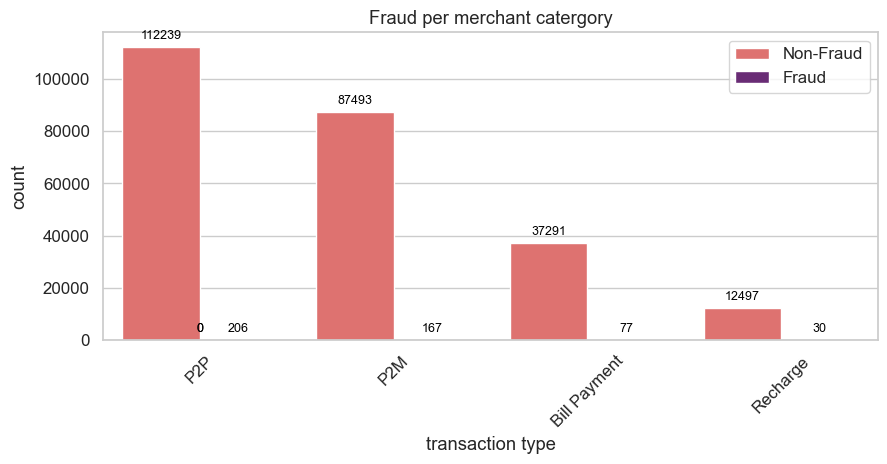

In [24]:
plt.figure(figsize=(10,4))
ax = sns.countplot(data=df,x='transaction type',hue='fraud_flag',palette='magma_r')
for p in ax.patches:
    ax.annotate(int(p.get_height()),(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='center',fontsize=9,color='black',xytext=(0,8),
               textcoords = 'offset points')
plt.title('Fraud per merchant catergory')
plt.xticks(rotation=45)
plt.legend(['Non-Fraud','Fraud'])
plt.show()

In [116]:
temp_df  = df[df['fraud_flag']==1]
sender_df = temp_df['sender_bank'].value_counts()
total_sender_df  = df['sender_bank'].value_counts()
fraud_rate_sender = (sender_df/total_sender_df)*100
fraud_rate_sender = fraud_rate_sender.reset_index()
#### 
receiver_df = temp_df['receiver_bank'].value_counts()
total_receiver_df  = df['receiver_bank'].value_counts()
fraud_rate_receiver = (receiver_df/total_receiver_df)*100
fraud_rate_receiver = fraud_rate_receiver.reset_index()

In [113]:
fraud_rate_sender

,sender_bank,count
0,Axis,0.195671
1,HDFC,0.165399
2,ICICI,0.221707
3,IndusInd,0.206571
4,Kotak,0.249601
5,PNB,0.208450
6,SBI,0.173863
7,Yes Bank,0.160901


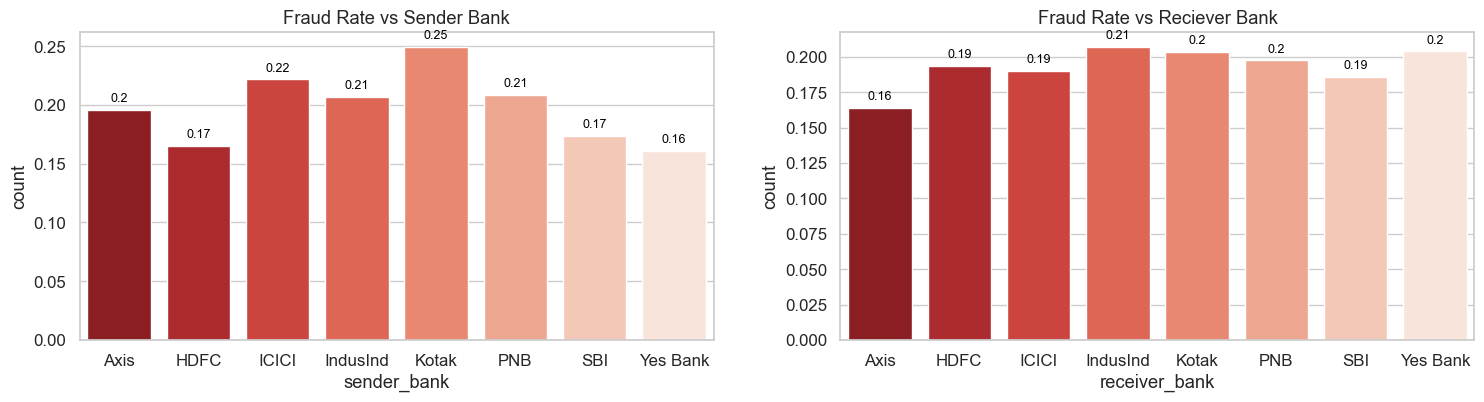

In [118]:
fig,ax = plt.subplots(1,2,figsize=(18,4))

sns.barplot(data =fraud_rate_sender,
             x = 'sender_bank',y='count',palette = 'Reds_r',ax=ax[0]
             )

for p in ax[0].patches:
    ax[0].annotate(round(p.get_height(),2),(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='center',fontsize=9,color='black',
                xytext = (0,8)
                ,textcoords='offset points')
ax[0].set_title('Fraud Rate vs Sender Bank')

sns.barplot(data = fraud_rate_receiver,
             x = 'receiver_bank',y='count',palette = 'Reds_r',ax=ax[1]
             )

for p in ax[1].patches:
    ax[1].annotate(round(p.get_height(),2),(p.get_x()+p.get_width()/2,p.get_height()),ha='center',va='center',fontsize=9,color='black',
                xytext = (0,8)
                ,textcoords='offset points')
ax[1].set_title('Fraud Rate vs Reciever Bank')

plt.show()

- Fraud Rate is second least through SBI bank despite having high Volume transaction.
- Most fraud are done through Kotak Bank, hence strict regulation should be present.
- Fraud Rate is almost uniform for Reciever bank i.e Sender bank matters,receiver bank doesnt.